# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

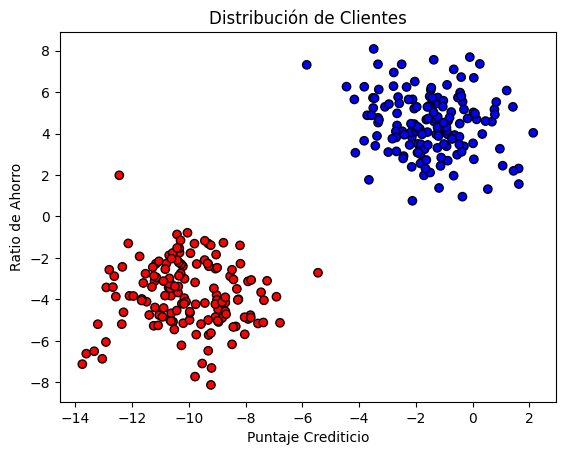

In [1]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [2]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model = Sequential([
    # Define la capa Dense con 1 neurona, activación 'sigmoid' y 2 variables de entrada
    Dense(units=1, activation='sigmoid', input_shape=(2,))
])
# ------------------------------

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [3]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# Usa model.compile(...)
# Define el optimizer usando tf.keras.optimizers.SGD y la loss adecuada.

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# ------------------------------

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [4]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# history = model.fit(..., epochs=..., verbose=1)

history = model.fit(X, y, epochs=50, verbose=1)
# ------------------------------

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8367 - loss: 0.4299      
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0593 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0392 
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0303 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0252 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0218 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0194 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0176 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0162 
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0150 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0140 
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

1024/1024 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


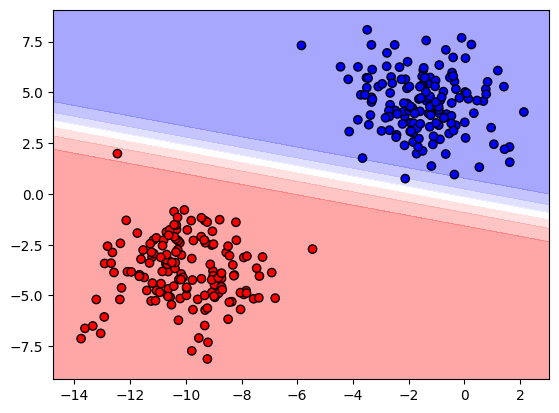

In [5]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.

**1. ¿Cuál es el valor del Bias?**

Al ejecutar el método model.get_weights(), Keras devuelve una lista con dos arreglos de NumPy. El primero corresponde a la matriz de pesos ($W$) de las conexiones de entrada, y el segundo contiene un único valor numérico que representa el Bias ($b$) o sesgo de la neurona. Aunque su valor exacto varía en cada entrenamiento debido a la inicialización aleatoria de la red, tras 50 épocas se estabiliza en el número ideal para desplazar la recta de predicción.

**¿Qué pasaría si fuera cero o no existiera?**

La ecuación matemática que define la frontera de decisión de este perceptrón es:$$w_1x_1 + w_2x_2 + b = 0$$Si el bias ($b$) fuera igual a cero (lo cual se puede forzar en Keras usando use_bias=False), la ecuación se reduciría a $w_1x_1 + w_2x_2 = 0$. Esto provoca que la línea recta de la frontera de decisión esté obligada a pasar exactamente por el origen de coordenadas $(0,0)$. Si los datos de los clientes de "Bajo Riesgo" y "Alto Riesgo" están agrupados en zonas que no pueden dividirse mediante una línea que cruce por el centro del plano, el modelo será incapaz de clasificarlos correctamente. El Bias es vital porque le otorga a la recta la libertad de desplazarse por el plano cartográfico.

**2. Regularización**

Si modificamos la capa del Paso 2 para incluir el regularizador L2 de la siguiente manera:
```
Dense(units=1, activation='sigmoid', input_shape=(2,), kernel_regularizer='l2')
```
* Cambio en el valor de los pesos: Se observa que los valores absolutos de los pesos ($w_1, w_2$) se vuelven significativamente más pequeños en comparación con el modelo original. Esto ocurre porque la regularización $L_2$ (Ridge) añade una penalización a la función de pérdida que castiga los pesos grandes para evitar que la red dependa excesivamente de una sola característica.

* Cambio en la suavidad de la frontera: Al disminuir la magnitud de los pesos,
los cambios en las variables de entrada producen variaciones menos drásticas en la salida de la función sigmoide. En la gráfica, esto se traduce en una zona de transición de color mucho más ancha, difuminada y suave entre la región azul y la roja. El modelo se vuelve menos "agresivo" con las clasificaciones limítrofes, lo que ayuda directamente a prevenir el sobreajuste (overfitting).

**3. No Linealidad (make_moons)**

**¿Es capaz el Perceptrón de una sola capa de separar estos datos?**

No, es completamente incapaz de separar los datos generados por make_moons de manera óptima.

Justificación teórica basada en la Separabilidad Lineal: El concepto fundamental en este escenario es la Separabilidad Lineal. Un conjunto de datos es linealmente separable si y solo si es posible trazar una línea recta (o hiperplano) que divida perfectamente las clases sin que se mezclen entre sí.

Limitación de la arquitectura: Un Perceptrón Simple de una sola capa calcula una combinación lineal de sus entradas ($w_1x_1 + w_2x_2 + b$) y le aplica una función de activación. Al no contar con capas intermedias que combinen las variables de otra forma, su frontera de decisión geométrica es estrictamente una línea recta.

Naturaleza del problema: El método make_moons genera una distribución de datos en forma de dos semicírculos o lunas entrelazadas. Debido a esta disposición geométrica, es matemáticamente imposible cruzar una línea recta que separe una luna de la otra.

Para resolver problemas con fronteras no lineales, la teoría exige migrar hacia un Perceptrón Multicapa (MLP), donde la inclusión de capas ocultas permite curvar y moldear la frontera de decisión según la complejidad de los datos.